In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="ywiApRFT8aql4UYEZzUL")
project = rf.workspace("roboflow-universe-projects").project("license-plate-recognition-rxg4e")
version = project.version(4)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [4]:
!pip install ultralytics easyocr opencv-python-headless


In [5]:
import os

# Set maximum number of images
MAX_TRAIN = 400
MAX_VALID = 100

# Dataset paths
train_img_dir = dataset.location + '/train/images'
train_lbl_dir = dataset.location + '/train/labels'
valid_img_dir = dataset.location + '/valid/images'
valid_lbl_dir = dataset.location + '/valid/labels'

# Reduce training images
train_imgs = sorted(os.listdir(train_img_dir))[:MAX_TRAIN]
train_lbls = [img.rsplit('.', 1)[0] + '.txt' for img in train_imgs]

for f in os.listdir(train_img_dir):
    if f not in train_imgs:
        os.remove(os.path.join(train_img_dir, f))

for f in os.listdir(train_lbl_dir):
    if f not in train_lbls:
        os.remove(os.path.join(train_lbl_dir, f))

# Reduce validation images
valid_imgs = sorted(os.listdir(valid_img_dir))[:MAX_VALID]
valid_lbls = [img.rsplit('.', 1)[0] + '.txt' for img in valid_imgs]

for f in os.listdir(valid_img_dir):
    if f not in valid_imgs:
        os.remove(os.path.join(valid_img_dir, f))

for f in os.listdir(valid_lbl_dir):
    if f not in valid_lbls:
        os.remove(os.path.join(valid_lbl_dir, f))

print("Dataset reduced for fast training.")



Dataset reduced for fast training.


In [6]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # Nano version = faster training
model.train(data=f'{dataset.location}/data.yaml', epochs=25)


Ultralytics 8.3.128 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/License-Plate-Recognition-4/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=1

train: Scanning /content/License-Plate-Recognition-4/train/labels... 200 images, 2 backgrounds, 0 corrupt: 100%|██████████| 200/200 [00:00<00:00, 1717.51it/s]

train: New cache created: /content/License-Plate-Recognition-4/train/labels.cache


albumentations: Blur(p=0.01, blur_limit=(3, 7)), MedianBlur(p=0.01, blur_limit=(3, 7)), ToGray(p=0.01, method='weighted_average', num_output_channels=3), CLAHE(p=0.01, clip_limit=(1.0, 4.0), tile_grid_size=(8, 8))
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 239.7±226.9 MB/s, size: 58.3 KB)


val: Scanning /content/License-Plate-Recognition-4/valid/labels... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<00:00, 2062.73it/s]

...

                   all         50         73      0.692      0.658      0.655      0.277



25 epochs completed in 1.221 hours.
Optimizer stripped from runs/detect/train2/weights/last.pt, 6.2MB
Optimizer stripped from runs/detect/train2/weights/best.pt, 6.2MB

Validating runs/detect/train2/weights/best.pt...
Ultralytics 8.3.128 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 2/2 [00:13<00:00,  6.74s/it]


                   all         50         73      0.696      0.659      0.656      0.277
Speed: 3.2ms preprocess, 256.3ms inference, 0.0ms loss, 1.7ms postprocess per image
Results saved to runs/detect/train2


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ac29a7ad310>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [8]:
from ultralytics import YOLO

# Load the best trained model
model = YOLO('runs/detect/train2/weights/best.pt')


In [10]:
from google.colab import files
uploaded = files.upload()  # Upload your image here
test_image_path = next(iter(uploaded))  # Get the first uploaded file


Saving download.jpg to download.jpg



0: 352x640 (no detections), 231.9ms
Speed: 2.9ms preprocess, 231.9ms inference, 1.1ms postprocess per image at shape (1, 3, 352, 640)


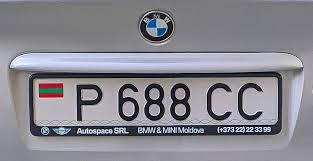

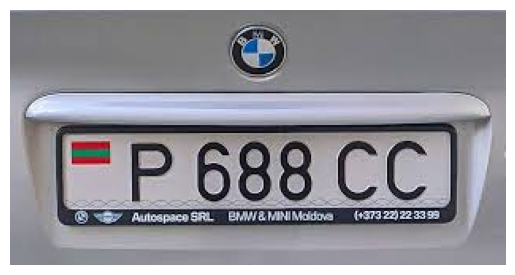

In [13]:
import cv2
import matplotlib.pyplot as plt

# Load the image
image = cv2.imread(test_image_path)

# Run YOLOv8 inference on the image
results = model(image)

# Draw the results (boxes and labels)
results[0].show()

# Optionally: To display results inline in Colab (matplotlib)
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


In [17]:
# Run validation on validation set
metrics = model.val()  # This uses validation data from the original training config

# Extract and print relevant metrics using the correct method
print("\n🔍 Evaluation Metrics on Validation Set:")
print(f"Mean Precision:     {metrics.box.p.mean():.4f}")
print(f"Mean Recall:        {metrics.box.r.mean():.4f}")
print(f"mAP@0.5:            {metrics.box.map50:.4f}")
print(f"mAP@0.5:0.95:       {metrics.box.map:.4f}")
print(f"Mean F1 Score:      {2 * (metrics.box.p.mean() * metrics.box.r.mean()) / (metrics.box.p.mean() + metrics.box.r.mean() + 1e-6):.4f}")


Ultralytics 8.3.128 🚀 Python-3.11.12 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1447.1±298.9 MB/s, size: 64.0 KB)


val: Scanning /content/License-Plate-Recognition-4/valid/labels.cache... 50 images, 0 backgrounds, 0 corrupt: 100%|██████████| 50/50 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:16<00:00,  4.02s/it]


                   all         50         73      0.696      0.659      0.656      0.277
Speed: 2.4ms preprocess, 301.9ms inference, 0.0ms loss, 2.2ms postprocess per image
Results saved to runs/detect/val3

🔍 Evaluation Metrics on Validation Set:
Mean Precision:     0.6963
Mean Recall:        0.6595
mAP@0.5:            0.6557
mAP@0.5:0.95:       0.2767
Mean F1 Score:      0.6774


In [19]:
!pip install fsspec==2025.3.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.4/194.4 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
datasets 3.6.0 requires fsspec[http]<=2025.3.0,>=2023.1.0, but you have fsspec 2025.3.2 which is incompatible.


In [21]:
!pip install transformers==4.30.0 datasets==2.9.0 timm==0.6.7
!pip install torchvision==0.13.1 torchaudio==0.13.1
!pip install accelerate==0.12.0
!pip install fsspec==2025.3.2



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.6/113.6 kB 2.8 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 60.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 462.8/462.8 kB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.0/510.0 kB 31.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.5/110.5 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.3/134.3 kB 11.8 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.21.1
    Uninstalling tokenizers-0.21.1:
      Successfully uninstalled tokenizers-0.21.1
  Attempting uninstall: dill
    Found existing installation: dill 0.3.8
    Uninstalling dill-0.3.8:
      Successfully u

In [22]:
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

# Load pretrained TrOCR model and processor
processor = TrOCRProcessor.from_pretrained('microsoft/trocr-base-handwritten')
model = VisionEncoderDecoderModel.from_pretrained('microsoft/trocr-base-handwritten').to('cuda' if torch.cuda.is_available() else 'cpu')

def run_trocr_on_plate(plate_img_path):
    image = Image.open(plate_img_path).convert("RGB")
    pixel_values = processor(images=image, return_tensors="pt").pixel_values
    pixel_values = pixel_values.to(model.device)

    generated_ids = model.generate(pixel_values)
    generated_text = processor.batch_decode(generated_ids, skip_special_tokens=True)[0]

    return generated_text.strip()



The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.


preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/772 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['decoder.output_projection.weight', 'encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [24]:
from ultralytics import YOLO
import cv2
import os

# Load YOLO model
yolo_model = YOLO("runs/detect/train2/weights/best.pt")

# Image to test
img_path = test_image_path
img = cv2.imread(img_path)

# Detect number plate
results = yolo_model(img)[0]

# Process first detected plate
for box in results.boxes:
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    plate_crop = img[y1:y2, x1:x2]
    crop_path = "plate_crop.jpg"
    cv2.imwrite(crop_path, plate_crop)

    # OCR with TrOCR
    ocr_text = run_trocr_on_plate(crop_path)
    print("TrOCR Output:", ocr_text)
    break



0: 352x640 (no detections), 420.2ms
Speed: 3.3ms preprocess, 420.2ms inference, 1.0ms postprocess per image at shape (1, 3, 352, 640)
